# 입력 feature 선택 및 XGBoost 모델 학습 및 검증

- feature 설정: `services/ai/configs/feature_config.yaml`
- 데이터: `services/ai/data/behavior/trial_*.json`
- 저장: `services/ai/train/model_joblib/xgboost/model.joblib`


> **트리비얼 검증 사전 (EDA 4번 결과 인용)**
>
> EDA 트리비얼 검증 (`eda_gyeom_2.ipynb` 4번 Personal EDA) 에서 high_smd_features 9개 중 다음 2개를 학습 입력 제외:
>
> - `time_to_first_click_ms` — 단독 분리 ~100%. `human_recorder` 의 첫 클릭 녹화 트리거 구조 산물. 수집 도구 변경 시 시그널 사라짐 → 진짜 매크로 시그니처 X.
> - `pre_click_mousemove_count` — 단독 분리 95%+. `lv2_collector` 의 `BEZIER_POINTS=20` 하드코딩 노출. lv3 collector 등 알고리즘 변경 시 무의미.
>
> 본 노트북은 나머지 7개 (`input_features_gyeom` yaml 그룹) 로만 학습.
>
> **단일 feature importance 50%+ 쏠리면 잠복 트리비얼 의심** — 6번 importance 다음의 사후 검증 안내 참조.

## 1. 데이터 준비


In [1]:
from __future__ import annotations

import json
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import yaml

SEED = 42
TEST_SIZE = 0.2
MODEL_NAME = "xgboost_gyeom"
LABEL_MAPPING = {"human": 0, "macro": 1}

# 데이터 경로 설정
ROOT = Path.cwd()

if ROOT.name != "model_experiment":
    raise Exception("데이터를 찾기 위해 작업 디렉토리 확인 필요")

CONFIG_PATH = Path("../../configs/feature_config.yaml")
DATA_DIR = Path("../../data/behavior")
MODEL_DIR = Path("../model_joblib") / MODEL_NAME

print("ROOT:", ROOT)
print("CONFIG_PATH:", CONFIG_PATH)
print("DATA_DIR:", DATA_DIR)
print("MODEL_DIR:", MODEL_DIR)


ROOT: C:\Users\SSAFY\Desktop\ai-macro-detection\services\ai\train\model_experiment
CONFIG_PATH: ..\..\configs\feature_config.yaml
DATA_DIR: ..\..\data\behavior
MODEL_DIR: ..\model_joblib\xgboost_gyeom


In [2]:
with CONFIG_PATH.open("r", encoding="utf-8") as f:
    feature_config = yaml.safe_load(f)

FEATURE_GROUPS = feature_config["groups"]
FEATURE_NAME_KO = feature_config.get("names_ko", {})
EXCLUDE_COLS = set(feature_config.get("exclude", []))
FEATURE_NAMES = [feature for group in FEATURE_GROUPS.values() for feature in group]

# DEVIATION (chan): yaml input_features_gyeom 그룹에서 학습 입력 7개 로드 (트리비얼 2개 제외 후 확정)
INPUT_FEATURES = feature_config["input_features_gyeom"]

def extract_label(payload: dict) -> str | None:
    label = payload.get("label")
    if isinstance(label, str):
        return label
    summary = payload.get("summary")
    if isinstance(summary, dict) and isinstance(summary.get("label"), str):
        return summary["label"]
    return None


def parse_path_pattern(value: object) -> tuple[float, float]:
    if not isinstance(value, str):
        return (np.nan, np.nan)

    parts = value.split("|", 1)
    if len(parts) != 2:
        return (np.nan, np.nan)

    distance_text = parts[0].replace("px", "").strip()
    straightness_text = parts[1].replace("straight", "").strip()

    try:
        return (float(distance_text), float(straightness_text))
    except ValueError:
        return (np.nan, np.nan)


def load_trials(data_dir: Path) -> pd.DataFrame:
    rows: list[dict] = []
    counters = {"total": 0, "kept": 0, "no_label": 0, "skipped_other": 0}

    for path in sorted(data_dir.glob("trial_*.json")):
        counters["total"] += 1
        payload = json.loads(path.read_text(encoding="utf-8"))

        label = extract_label(payload)
        if label is None:
            counters["no_label"] += 1
            continue
        if label not in LABEL_MAPPING:
            counters["skipped_other"] += 1
            continue

        summary = payload.get("summary") or {}
        metrics = payload.get("metrics") or {}
        row = {
            "trial_id": int(payload.get("trialId") or payload.get("trial_id") or 0),
            "label": label,
        }
        if isinstance(summary, dict):
            row.update(summary)
        if isinstance(metrics, dict):
            row.update(metrics)
        rows.append(row)
        counters["kept"] += 1

    df = pd.DataFrame(rows).sort_values("trial_id").reset_index(drop=True)
    print("load counters:", counters)
    return df


def add_pre_click_path_features(df: pd.DataFrame) -> None:
    for win in [300, 500]:
        raw_col = f"pre_click_mouse_path_pattern_{win}ms"
        dist_col = f"pre_click_path_{win}ms_total_distance_px"
        straight_col = f"pre_click_path_{win}ms_straightness"
        if raw_col not in df.columns or (dist_col in df.columns and straight_col in df.columns):
            continue
        parsed = df[raw_col].map(parse_path_pattern)
        df[dist_col] = parsed.map(lambda x: x[0])
        df[straight_col] = parsed.map(lambda x: x[1])


df = load_trials(DATA_DIR)
add_pre_click_path_features(df)

display(df["label"].value_counts().rename_axis("label").reset_index(name="count"))
print("configured feature count:", len(FEATURE_NAMES))
print("INPUT_FEATURES (gyeom):", len(INPUT_FEATURES))
display(pd.DataFrame({"feature": INPUT_FEATURES, "feature_ko": [FEATURE_NAME_KO.get(f, f) for f in INPUT_FEATURES]}))


load counters: {'total': 152, 'kept': 152, 'no_label': 0, 'skipped_other': 0}


,label,count
0,macro,101
1,human,51


configured feature count: 44
INPUT_FEATURES (gyeom): 7


,feature,feature_ko
0,inter_click_interval_ms,클릭 간격
1,mouse_speed_change_mean,속도 변화
2,mouse_total_travel_distance_px,총 이동 거리
3,mouse_path_curvature_mean,경로 곡률
4,mouse_avg_speed_px_per_ms,평균 속도
5,mouse_acceleration_mean,가속도 변화
6,mouse_max_speed_px_per_ms,최대 속도


## 2. 데이터 전처리


In [3]:
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    log_loss,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.preprocessing import StandardScaler

present_features = [f for f in INPUT_FEATURES if f in df.columns]
missing_features = [f for f in INPUT_FEATURES if f not in df.columns]

X_all = df[present_features].apply(pd.to_numeric, errors="coerce")
usable_features = [f for f in present_features if X_all[f].notna().any()]
dropped_all_nan = [f for f in present_features if f not in usable_features]

X = X_all[usable_features]
y = df["label"].map(LABEL_MAPPING).astype(int).to_numpy()
feature_names = list(X.columns)

x_train, x_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=y,
)

n_neg = int((y_train == 0).sum())
n_pos = int((y_train == 1).sum())
SCALE_POS_WEIGHT = n_neg / max(n_pos, 1)

print("usable features:", len(usable_features), "/", len(INPUT_FEATURES))
print("missing features:", missing_features)
print("dropped all-NaN features:", dropped_all_nan)
print("train shape:", x_train.shape, "val shape:", x_val.shape)
print("train class counts:", dict(zip(*np.unique(y_train, return_counts=True))))
print("val class counts:", dict(zip(*np.unique(y_val, return_counts=True))))
print("scale_pos_weight:", SCALE_POS_WEIGHT)


usable features: 7 / 7
missing features: []
dropped all-NaN features: []
train shape: (121, 7) val shape: (31, 7)
train class counts: {0: 41, 1: 80}
val class counts: {0: 10, 1: 21}
scale_pos_weight: 0.5125


## 3. 모델 준비


In [4]:
from xgboost import XGBClassifier

def build_model(seed: int = SEED):
    return Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            (
                "clf",
                XGBClassifier(
                    n_estimators=400,
                    max_depth=3,
                    learning_rate=0.03,
                    subsample=0.9,
                    colsample_bytree=0.9,
                    objective="binary:logistic",
                    eval_metric="logloss",
                    scale_pos_weight=SCALE_POS_WEIGHT,
                    tree_method="hist",
                    random_state=seed,
                    n_jobs=-1,
                ),
            ),
        ]
    )


def predict_macro_proba(fitted_model, x) -> np.ndarray:
    if hasattr(fitted_model, "predict_proba"):
        return np.asarray(fitted_model.predict_proba(x))[:, 1]
    decision = np.asarray(fitted_model.decision_function(x), dtype=float)
    return 1.0 / (1.0 + np.exp(-decision))


def evaluate_binary(y_true: np.ndarray, proba: np.ndarray, threshold: float = 0.5) -> dict[str, float]:
    pred = (proba >= threshold).astype(int)
    out = {
        "accuracy": float(accuracy_score(y_true, pred)),
        "precision": float(precision_score(y_true, pred, zero_division=0)),
        "recall": float(recall_score(y_true, pred, zero_division=0)),
        "f1": float(f1_score(y_true, pred, zero_division=0)),
        "average_precision": float(average_precision_score(y_true, proba)),
    }
    try:
        out["roc_auc"] = float(roc_auc_score(y_true, proba))
    except ValueError:
        out["roc_auc"] = float("nan")
    try:
        out["log_loss"] = float(log_loss(y_true, proba, labels=[0, 1]))
    except ValueError:
        out["log_loss"] = float("nan")
    return out


model = build_model(SEED)
model


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a feat

## 4. 모델 학습


In [5]:
model.fit(x_train, y_train)

train_proba = predict_macro_proba(model, x_train)
val_proba = predict_macro_proba(model, x_val)

train_metrics = evaluate_binary(y_train, train_proba)
val_metrics = evaluate_binary(y_val, val_proba)

metrics_df = pd.DataFrame(
    [
        {"split": "train", **train_metrics},
        {"split": "validation", **val_metrics},
    ]
)
display(metrics_df)

cm = confusion_matrix(y_val, (val_proba >= 0.5).astype(int), labels=[0, 1])
cm_df = pd.DataFrame(cm, index=["actual_human", "actual_macro"], columns=["pred_human", "pred_macro"])
display(cm_df)


,split,accuracy,precision,recall,f1,average_precision,roc_auc,log_loss
0,train,1.000000,1.000000,1.0,1.000000,1.0,1.0,0.02626
1,validation,0.967742,0.954545,1.0,0.976744,1.0,1.0,0.10160


,pred_human,pred_macro
actual_human,9,1
actual_macro,0,21


## 5. 모델 검증


In [6]:
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "average_precision": "average_precision",
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_result = cross_validate(
    build_model(SEED),
    X,
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False,
)

cv_summary = pd.DataFrame(
    [
        {
            "metric": metric.replace("test_", ""),
            "mean": float(values.mean()),
            "std": float(values.std(ddof=1)),
        }
        for metric, values in cv_result.items()
        if metric.startswith("test_")
    ]
).sort_values("metric")

display(cv_summary)


,metric,mean,std
0,accuracy,0.993548,0.014426
5,average_precision,1.000000,0.000000
3,f1,0.995122,0.010908
1,precision,0.990476,0.021296
2,recall,1.000000,0.000000
4,roc_auc,1.000000,0.000000


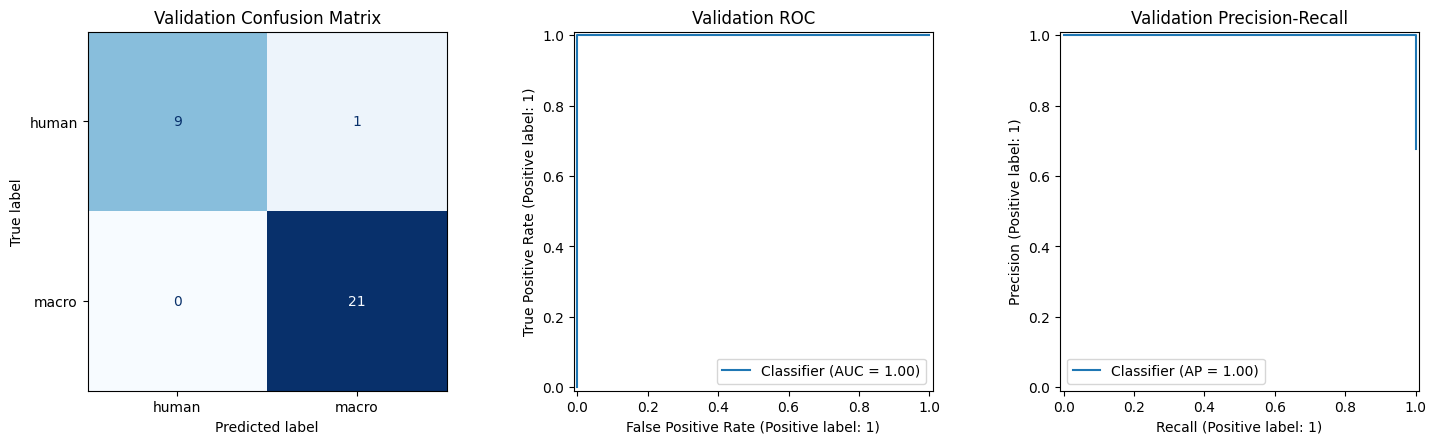

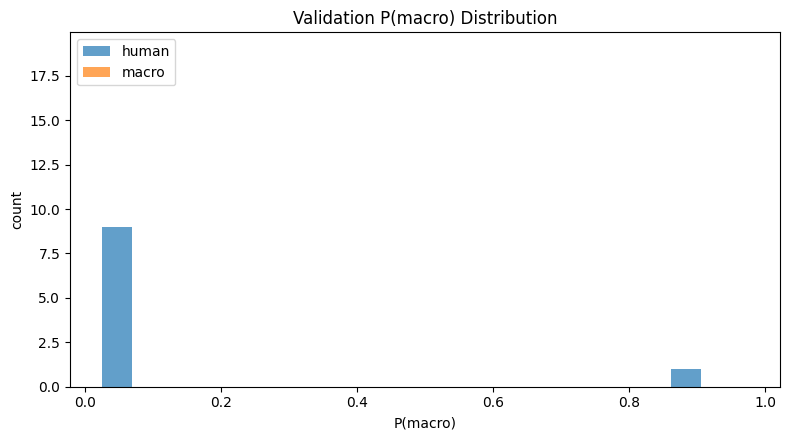

In [7]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, PrecisionRecallDisplay, RocCurveDisplay

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

ConfusionMatrixDisplay.from_predictions(
    y_val,
    (val_proba >= 0.5).astype(int),
    display_labels=["human", "macro"],
    cmap="Blues",
    colorbar=False,
    ax=axes[0],
)
axes[0].set_title("Validation Confusion Matrix")

RocCurveDisplay.from_predictions(y_val, val_proba, ax=axes[1])
axes[1].set_title("Validation ROC")

PrecisionRecallDisplay.from_predictions(y_val, val_proba, ax=axes[2])
axes[2].set_title("Validation Precision-Recall")

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4.5))
plt.hist(val_proba[y_val == 0], bins=20, alpha=0.7, label="human")
plt.hist(val_proba[y_val == 1], bins=20, alpha=0.7, label="macro")
plt.title("Validation P(macro) Distribution")
plt.xlabel("P(macro)")
plt.ylabel("count")
plt.legend()
plt.tight_layout()
plt.show()


In [8]:
clf = model.named_steps["clf"]
importance_df = pd.DataFrame(
    {
        "feature": feature_names,
        "feature_ko": [FEATURE_NAME_KO.get(f, f) for f in feature_names],
        "importance": clf.feature_importances_,
    }
).sort_values("importance", ascending=False)
display(importance_df.head(30))


,feature,feature_ko,importance
0,inter_click_interval_ms,클릭 간격,0.526150
1,mouse_speed_change_mean,속도 변화,0.400314
6,mouse_max_speed_px_per_ms,최대 속도,0.039943
4,mouse_avg_speed_px_per_ms,평균 속도,0.033593
2,mouse_total_travel_distance_px,총 이동 거리,0.000000
3,mouse_path_curvature_mean,경로 곡률,0.000000
5,mouse_acceleration_mean,가속도 변화,0.000000


> **트리비얼 검증 사후 — importance 결과 점검**
>
> 위 표에서 단일 feature 가 importance 의 **50%+** 를 차지하면 잠복 트리비얼 의심:
>
> 1. 해당 feature 단독 분류 정확도 측정 (`from sklearn.linear_model import LogisticRegression; cross_val_score(LogisticRegression(max_iter=1000), X_single, y, cv=5, scoring="accuracy")`)
> 2. 95%+ 면 잠복 트리비얼 확정 → `input_features_gyeom` 에서 제거 + EDA 4번 `TRIVIAL_RISK` 리스트 갱신 검토
> 3. ~50% 분담 (mouse 그룹 여러 feature 가 비슷하게 기여) 이면 정상 패턴
>
> recall < 0.85 인 경우도 importance top feature 가 트리비얼이라 모델이 그 feature 만 의존하는 상황일 수 있음.

## 6. Robustness 분석

ADR 5.3 검증 기준 답 + 일반화 가능성 정량 추정.

- 6-1. Feature ablation: 7 feature 각각 1개씩 빼고 학습 → 의존도 측정
- 6-2. Noise robustness: validation set 에 가우시안 noise → recall 변화
- 6-3. **Trivial removed (★)**: `inter_click_interval_ms` 빼고 6 feature CV → 단독 트리비얼 (1.0) 대비 의미 있는 상회 여부 = ADR 5.3 직접 답

### 6-1. Feature ablation

7 feature 각각 1개씩 제외 → 5-fold CV recall / f1 / roc_auc 측정.
가장 의존도 높은 feature = 제외 시 recall 가장 큰 폭 하락.

**해석 기준**:
- 큰 폭 하락 (recall < 0.85) → 그 feature 단독 의존
- 안정적 (변화 < 5%) → redundant 시그널 (다른 feature 가 보완)
- `inter_click_interval_ms` 제외 시 변화가 핵심 (트리비얼 의존도 정량화)

In [9]:
ablation_results = []
for excluded in INPUT_FEATURES:
    remaining = [f for f in INPUT_FEATURES if f != excluded]
    X_sub = df[remaining].apply(pd.to_numeric, errors="coerce")
    cv_result = cross_validate(
        build_model(SEED), X_sub, y,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
        scoring={"recall": "recall", "f1": "f1", "roc_auc": "roc_auc"},
        n_jobs=-1,
    )
    ablation_results.append({
        "excluded_feature": excluded,
        "excluded_ko": FEATURE_NAME_KO.get(excluded, excluded),
        "n_features": len(remaining),
        "recall_mean": float(cv_result["test_recall"].mean()),
        "recall_std": float(cv_result["test_recall"].std(ddof=1)),
        "f1_mean": float(cv_result["test_f1"].mean()),
        "roc_auc_mean": float(cv_result["test_roc_auc"].mean()),
    })

ablation_df = pd.DataFrame(ablation_results).sort_values("recall_mean")
display(ablation_df)

,excluded_feature,excluded_ko,n_features,recall_mean,recall_std,f1_mean,roc_auc_mean
0,inter_click_interval_ms,클릭 간격,6,1.0,0.0,0.995122,1.0
1,mouse_speed_change_mean,속도 변화,6,1.0,0.0,0.995122,1.0
2,mouse_total_travel_distance_px,총 이동 거리,6,1.0,0.0,0.995122,1.0
3,mouse_path_curvature_mean,경로 곡률,6,1.0,0.0,0.995122,1.0
4,mouse_avg_speed_px_per_ms,평균 속도,6,1.0,0.0,0.995122,1.0
5,mouse_acceleration_mean,가속도 변화,6,1.0,0.0,0.995122,1.0
6,mouse_max_speed_px_per_ms,최대 속도,6,1.0,0.0,0.995122,1.0


### 6-2. Noise robustness

Validation set 에 점진적 가우시안 noise 추가 → recall / accuracy 변화.
`feature_stds` 는 train set 만으로 측정 (leak 방지).

**해석 기준**:
- noise 0.10 (10% std) 까지 recall 유지 → 일반화 가능성 시그널
- 작은 noise 에서도 급락 → 정확한 분포 외우기 (overfit 의심)

C:\Users\SSAFY\miniforge3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
C:\Users\SSAFY\miniforge3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
C:\Users\SSAFY\miniforge3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
C:\Users\SSAFY\miniforge3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
C:\Users\SSAFY\miniforge3\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SimpleImputer was fitted with feature names
  warnings.warn(
C:\Users\SSAFY\miniforge3\Lib\site-

,noise_level,accuracy,precision,recall,f1,average_precision,roc_auc,log_loss
0,0.000,0.967742,0.954545,1.000000,0.976744,1.0,1.0,0.101600
1,0.025,0.967742,0.954545,1.000000,0.976744,1.0,1.0,0.102047
2,0.050,0.935484,0.913043,1.000000,0.954545,1.0,1.0,0.177962
3,0.075,0.967742,0.954545,1.000000,0.976744,1.0,1.0,0.102357
4,0.100,1.000000,1.000000,1.000000,1.000000,1.0,1.0,0.027890
5,0.150,0.967742,0.954545,1.000000,0.976744,1.0,1.0,0.104297
6,0.200,1.000000,1.000000,1.000000,1.000000,1.0,1.0,0.029529
7,0.500,0.935484,1.000000,0.904762,0.950000,1.0,1.0,0.225703


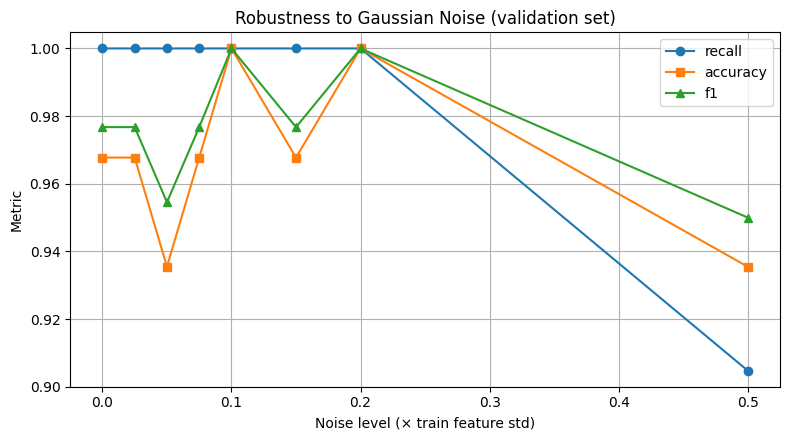

In [10]:
noise_levels = [0.0, 0.025, 0.05, 0.075, 0.10, 0.15, 0.20, 0.50]
noise_results = []
rng = np.random.RandomState(SEED)

# leak 방지: train set 에서만 std 측정
feature_stds = x_train.std().values

for noise_std in noise_levels:
    noise = rng.normal(0, 1, size=x_val.shape) * feature_stds * noise_std
    X_val_noisy = x_val.values + noise
    proba = predict_macro_proba(model, X_val_noisy)
    metrics = evaluate_binary(y_val, proba)
    noise_results.append({"noise_level": noise_std, **metrics})

noise_df = pd.DataFrame(noise_results)
display(noise_df)

import matplotlib.pyplot as plt
plt.figure(figsize=(8, 4.5))
plt.plot(noise_df["noise_level"], noise_df["recall"], marker="o", label="recall")
plt.plot(noise_df["noise_level"], noise_df["accuracy"], marker="s", label="accuracy")
plt.plot(noise_df["noise_level"], noise_df["f1"], marker="^", label="f1")
plt.xlabel("Noise level (× train feature std)")
plt.ylabel("Metric")
plt.title("Robustness to Gaussian Noise (validation set)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### 6-3. Trivial removed (★ ADR 5.3 핵심)

`inter_click_interval_ms` 제외, 6 feature 만으로 5-fold CV. 7 feature CV 와 비교.

**ADR 5.3 답 기준**:
- 6 feature recall ≥ 0.98 → 다른 feature 진짜 시그널 학습. 모델 가치 ↑. lv3 가능성 ↑.
- 6 feature recall ≈ 0.95 → 다른 feature 도 동일 분리도 (도미노). lv3 처음부터 재검증.
- 6 feature recall < 0.90 → 트리비얼 핵심 의존. 일반화 어려움. 데이터셋/feature 재설계 필요.

In [11]:
TRIVIAL_REMOVED = [f for f in INPUT_FEATURES if f != "inter_click_interval_ms"]
X_no_trivial = df[TRIVIAL_REMOVED].apply(pd.to_numeric, errors="coerce")

cv_no_trivial = cross_validate(
    build_model(SEED), X_no_trivial, y,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    scoring=scoring,
    n_jobs=-1,
)
no_trivial_summary = pd.DataFrame([
    {"metric": m.replace("test_", ""), "mean": float(v.mean()), "std": float(v.std(ddof=1))}
    for m, v in cv_no_trivial.items() if m.startswith("test_")
]).sort_values("metric").reset_index(drop=True)

print("=== 7 feature (with inter_click_interval_ms) ===")
display(cv_summary)
print("=== 6 feature (without inter_click_interval_ms) ===")
display(no_trivial_summary)

diff_df = cv_summary.merge(no_trivial_summary, on="metric", suffixes=("_7feat", "_6feat"))
diff_df["delta"] = diff_df["mean_6feat"] - diff_df["mean_7feat"]
print("=== diff (6feat - 7feat) ===")
display(diff_df[["metric", "mean_7feat", "mean_6feat", "delta"]])

=== 7 feature (with inter_click_interval_ms) ===


,metric,mean,std
0,accuracy,0.993548,0.014426
5,average_precision,1.000000,0.000000
3,f1,0.995122,0.010908
1,precision,0.990476,0.021296
2,recall,1.000000,0.000000
4,roc_auc,1.000000,0.000000


=== 6 feature (without inter_click_interval_ms) ===


,metric,mean,std
0,accuracy,0.993548,0.014426
1,average_precision,1.000000,0.000000
2,f1,0.995122,0.010908
3,precision,0.990476,0.021296
4,recall,1.000000,0.000000
5,roc_auc,1.000000,0.000000


=== diff (6feat - 7feat) ===


,metric,mean_7feat,mean_6feat,delta
0,accuracy,0.993548,0.993548,0.0
1,average_precision,1.000000,1.000000,0.0
2,f1,0.995122,0.995122,0.0
3,precision,0.990476,0.990476,0.0
4,recall,1.000000,1.000000,0.0
5,roc_auc,1.000000,1.000000,0.0


## 7. 종합 리포트

### 6-1 ablation
- 가장 의존도 높은 feature = `ablation_df` 첫 행 (recall_mean 가장 낮음)
- 안정적 (변화 < 5%) feature = recall_mean 1.0 근처

### 6-2 noise decay
- recall 첫 큰 하락 시점 = `noise_df` 에서 recall 처음 < 0.95 인 noise_level
- noise 0.10 시점 recall = 일반화 가능성 핵심 지표

### 6-3 ★ ADR 5.3 검증 기준 답
- 7 feature CV recall vs 6 feature CV recall (`diff_df` 의 delta 행 참조)
- 단독 트리비얼 (`inter_click_interval_ms` 단독 CV acc 1.000) 대비 6 feature recall 의미 있는 상회 여부

### Phase 2 추천 (1B-3 결과에 따라 분기)
- **6 feature recall ≥ 0.98**: 다른 feature 가 진짜 시그널 학습. → LightGBM/CatBoost 비교 (`pip install lightgbm catboost`), 295 결과로 Phase 2 진입.
- **6 feature recall ≈ 0.95**: 다른 feature 도 동일 분리도 (도미노). → lv3 collector 데이터 우선, 본질적 분리도 재검증.
- **6 feature recall < 0.90**: 트리비얼 핵심 의존. → 데이터셋/feature 재설계, lv2 한계 정량 증거 ADR 등록.

본 노트북 결과를 `tasks/todo.md` Phase 1B Review 섹션에 옮겨 ADR 5.3 판정 갱신.